In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('cairo_weather_2022_2023_analyzed.csv', index_col='date', parse_dates=True)

df = df.asfreq('D')  

print(df.index.freq)
print(df.shape)
df.head()

<Day>
(730, 10)


,temperature_mean,temperature_max,temperature_min,precipitation,temp_rolling_7d,temp_rolling_30d,month,month_name,temp_rolling_std_7d,temp_zscore
date,,,,,,,,,,
2022-01-01,12.20,18.29,7.63,0.51,NaN,NaN,1,Jan,NaN,NaN
2022-01-02,12.18,18.83,6.79,0.33,NaN,NaN,1,Jan,NaN,NaN
2022-01-03,12.91,19.76,8.35,0.40,NaN,NaN,1,Jan,NaN,NaN
2022-01-04,12.02,18.59,7.90,0.15,NaN,NaN,1,Jan,NaN,NaN
2022-01-05,12.67,19.56,7.71,0.00,NaN,NaN,1,Jan,NaN,NaN


In [2]:
print("Missing values before handling:")
print(df.isna().sum())

df['temperature_mean'] = df['temperature_mean'].interpolate(method='time', limit_direction='both')

print("\nMissing values after handling (temperature_mean):")
print(df['temperature_mean'].isna().sum())

Missing values before handling:
temperature_mean        0
temperature_max         0
temperature_min         0
precipitation           0
temp_rolling_7d         6
temp_rolling_30d       29
month                   0
month_name              0
temp_rolling_std_7d     6
temp_zscore            29
dtype: int64

Missing values after handling (temperature_mean):
0


In [3]:
day_of_year = df.index.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * day_of_year / 365)
df['doy_cos'] = np.cos(2 * np.pi * day_of_year / 365)

df['lag_1'] = df['temperature_mean'].shift(1)      
df['lag_7'] = df['temperature_mean'].shift(7)      
df['lag_365'] = df['temperature_mean'].shift(365)  

df[['temperature_mean', 'doy_sin', 'doy_cos', 'lag_1', 'lag_7', 'lag_365']].tail()

,temperature_mean,doy_sin,doy_cos,lag_1,lag_7,lag_365
date,,,,,,
2023-12-27,15.97,-6.880243e-02,0.997630,15.73,14.51,13.45
2023-12-28,16.30,-5.161967e-02,0.998667,15.97,13.73,12.59
2023-12-29,16.42,-3.442161e-02,0.999407,16.30,13.45,13.11
2023-12-30,16.10,-1.721336e-02,0.999852,16.42,14.79,14.69
2023-12-31,15.29,6.432491e-16,1.000000,16.10,16.30,13.78


In [4]:
split_date = df.index.max() - pd.Timedelta(days=21)
train, test = df.loc[:split_date], df.loc[split_date + pd.Timedelta(days=1):]

print("Train range:", train.index.min(), "→", train.index.max(), f"({len(train)} days)")
print("Test range:", test.index.min(), "→", test.index.max(), f"({len(test)} days)")

Train range: 2022-01-01 00:00:00 → 2023-12-10 00:00:00 (709 days)
Test range: 2023-12-11 00:00:00 → 2023-12-31 00:00:00 (21 days)


In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_stat, adf_p, *_ = adfuller(train['temperature_mean'].dropna())
kpss_stat, kpss_p, *_ = kpss(train['temperature_mean'].dropna(), regression='c', nlags='auto')

print(f"ADF  -> statistic={adf_stat:.4f} | p-value={adf_p:.4f}")
print(f"KPSS -> statistic={kpss_stat:.4f} | p-value={kpss_p:.4f}")

if adf_p < 0.05:
    adf_result = "Stationary"
else:
    adf_result = "Non-stationary"

if kpss_p < 0.05:
    kpss_result = "Non-stationary"
else:
    kpss_result = "Stationary"

print("\nADF conclusion:", adf_result)
print("KPSS conclusion:", kpss_result)

ADF  -> statistic=-1.7029 | p-value=0.4296
KPSS -> statistic=0.5966 | p-value=0.0229

ADF conclusion: Non-stationary
KPSS conclusion: Non-stationary


In [7]:
train_diff1 = train['temperature_mean'].diff(1).dropna()

adf_stat2, adf_p2, *_ = adfuller(train_diff1)
print(f"After first differencing -> ADF p-value: {adf_p2:.6f}")

if adf_p2 < 0.05:
    print("Result: Now STATIONARY after 1 round of differencing (d=1)")
else:
    print("Result: Still non-stationary, may need more differencing")

After first differencing -> ADF p-value: 0.000000
Result: Now STATIONARY after 1 round of differencing (d=1)


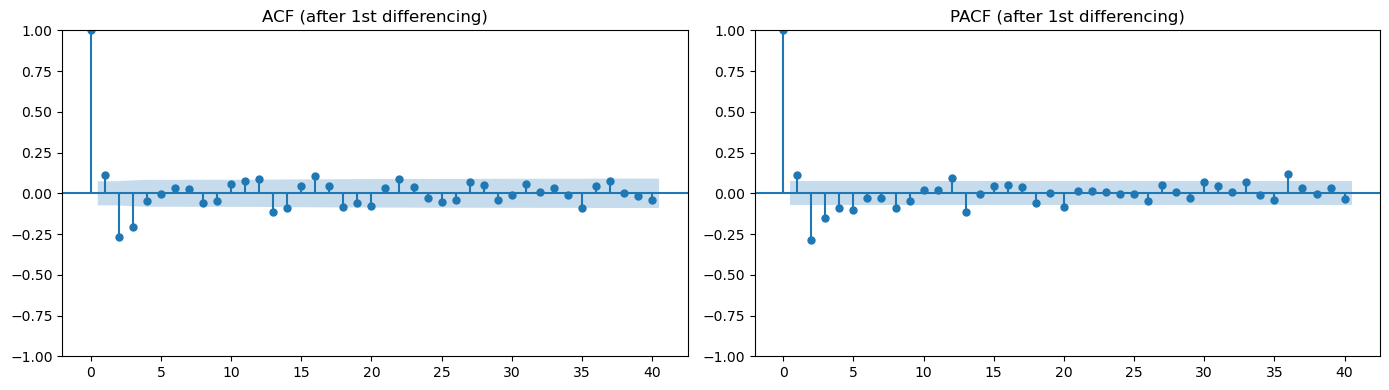

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff1, lags=40, ax=axes[0])
axes[0].set_title('ACF (after 1st differencing)')

plot_pacf(train_diff1, lags=40, ax=axes[1])
axes[1].set_title('PACF (after 1st differencing)')

plt.tight_layout()
plt.savefig('acf_pacf_diff1.png', dpi=100)
plt.show()

In [9]:
!pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ---------------------------------------- 711.9/711.9 kB 1.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.5 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.4 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.8 MB 1.5 MB/s eta 0:00:02
   ------------------ --------------------- 1.3/2.8 MB 1.3 MB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.8 MB 1.4 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.8 MB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------- 

In [10]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train['temperature_mean'],
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2453.895, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2546.216, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2539.245, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2530.905, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2544.225, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2459.164, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2452.540, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2523.297, Time=0.23 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2481.365, Time=0.09 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2453.844, Time=0.31 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2467.011, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2455.841, Time=0.54 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=2450.572, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2521.304, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[0]          

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_train = train[['doy_sin', 'doy_cos']]

model = SARIMAX(
    train['temperature_mean'],
    exog=exog_train,
    order=(2, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:       temperature_mean   No. Observations:                  709
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -1203.392
Date:                Sat, 08 Aug 2026   AIC                           2418.785
Time:                        02:53:28   BIC                           2446.142
Sample:                    01-01-2022   HQIC                          2429.356
                         - 12-10-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
doy_sin       -4.0694      0.406    -10.024      0.000      -4.865      -3.274
doy_cos       -8.5269      0.363    -23.503      0.000      -9.238      -7.816
ar.L1          0.9546      0.028     34.559      0.0

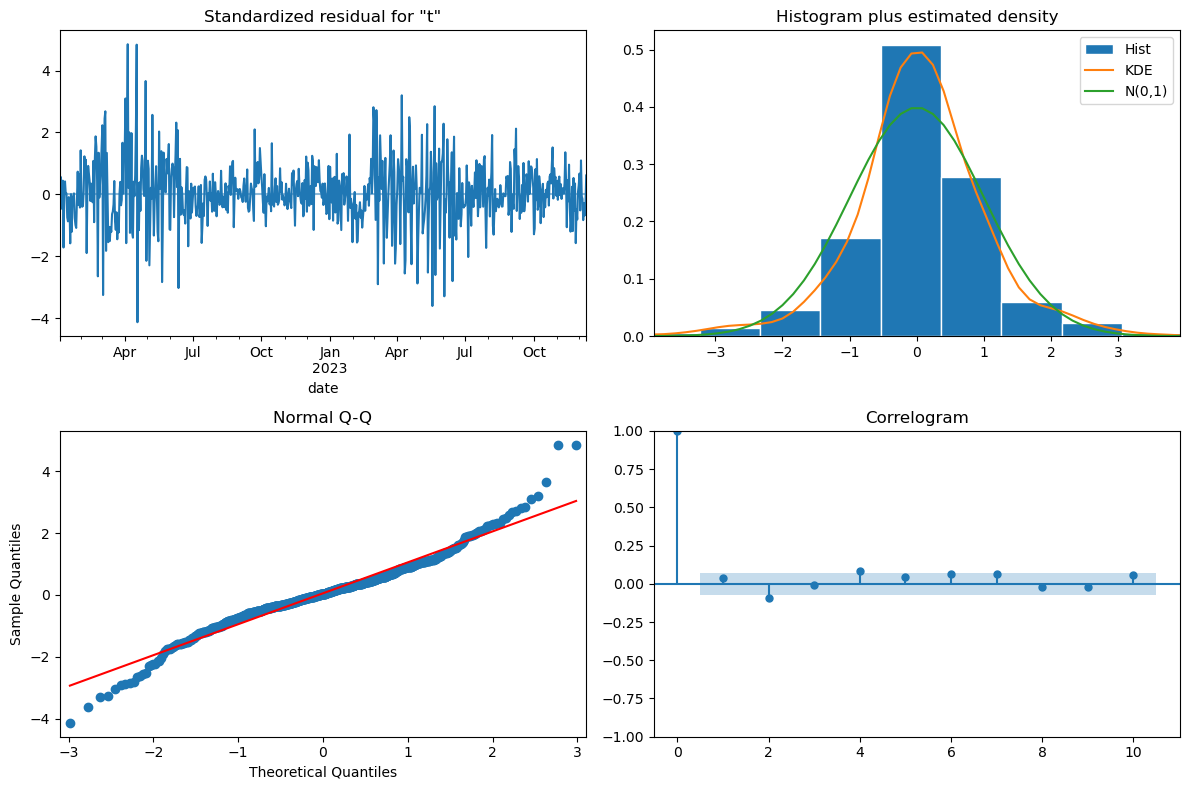

In [12]:
fig = fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=100)
plt.show()

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_result = acorr_ljungbox(fit.resid.dropna(), lags=[10, 20, 30], return_df=True)
print(lb_result)

      lb_stat  lb_pvalue
10  20.599523   0.024066
20  43.454179   0.001780
30  53.048039   0.005858


In [14]:
model2 = SARIMAX(
    train['temperature_mean'],
    exog=exog_train,
    order=(3, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit2 = model2.fit(disp=False)

print("AIC model (2,1,1):", fit.aic)
print("AIC model (3,1,2):", fit2.aic)

lb_result2 = acorr_ljungbox(fit2.resid.dropna(), lags=[10, 20, 30], return_df=True)
print("\nLjung-Box for (3,1,2):")
print(lb_result2)

AIC model (2,1,1): 2418.784745225923
AIC model (3,1,2): 2402.32829517876

Ljung-Box for (3,1,2):
      lb_stat  lb_pvalue
10  41.555626   0.000009
20  56.848832   0.000022
30  62.376092   0.000470


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Model Selection Decision

Two candidate models were compared:
- **SARIMAX(2,1,1) + harmonic exog (doy_sin, doy_cos):** AIC = 2418.78, converged cleanly.
- **SARIMAX(3,1,2) + harmonic exog:** AIC = 2402.33 (lower), but failed to converge
  (ConvergenceWarning) and produced *worse* Ljung-Box p-values at all tested lags
  (10, 20, 30), meaning it left more, not less, residual autocorrelation.

**Decision: proceed with SARIMAX(2,1,1) + harmonic regression.** A lower AIC alone
is not sufficient justification when the more complex model fails to converge reliably
and does not actually reduce residual autocorrelation.

**Known limitation:** the Ljung-Box test rejects the null hypothesis of "no residual
autocorrelation" at lags 10/20/30 (p < 0.05) even for the chosen model. With 709
observations, the test is highly sensitive to even small remaining structure — visually,
the correlogram shows no lag outside the confidence band. The residual diagnostics also
show mildly heavy tails (Jarque-Bera rejects normality). This means forecast confidence
intervals should be treated as approximate rather than exact, but the point forecasts
themselves remain usable. A longer training history (3+ full seasonal cycles) or an
explicit SARIMA seasonal term would likely resolve this further, but was not
computationally practical here given the 365-day seasonal period.

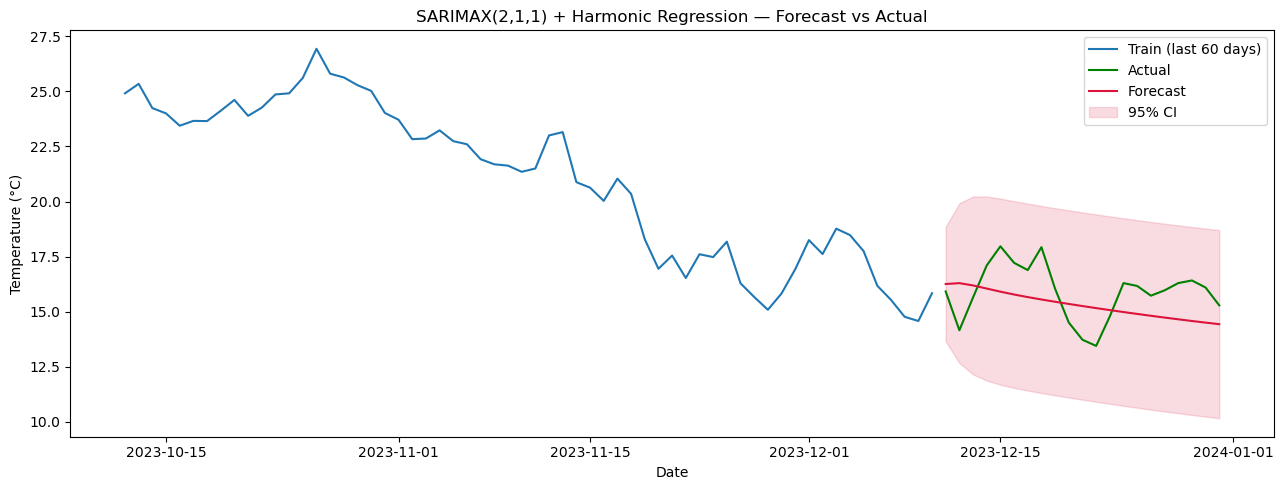

In [15]:
exog_test = test[['doy_sin', 'doy_cos']]

forecast = fit.get_forecast(steps=len(test), exog=exog_test)
pred_mean = forecast.predicted_mean
ci = forecast.conf_int(alpha=0.05)

plt.figure(figsize=(13, 5))
plt.plot(train.index[-60:], train['temperature_mean'][-60:], label='Train (last 60 days)')
plt.plot(test.index, test['temperature_mean'], label='Actual', color='green')
plt.plot(test.index, pred_mean, label='Forecast', color='crimson')
plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1], color='crimson', alpha=0.15, label='95% CI')
plt.legend()
plt.title('SARIMAX(2,1,1) + Harmonic Regression — Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('forecast_vs_actual.png', dpi=100)
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['temperature_mean'], pred_mean)
rmse = np.sqrt(mean_squared_error(test['temperature_mean'], pred_mean))
mape = np.mean(np.abs((test['temperature_mean'] - pred_mean) / test['temperature_mean'])) * 100

print(f"MAE  = {mae:.3f} °C")
print(f"RMSE = {rmse:.3f} °C")
print(f"MAPE = {mape:.2f}%")

MAE  = 1.275 °C
RMSE = 1.397 °C
MAPE = 8.03%


In [19]:
naive_pred = pd.Series(train['temperature_mean'].iloc[-1], index=test.index)
naive_mae = mean_absolute_error(test['temperature_mean'], naive_pred)

seasonal_naive_pred = train['temperature_mean'].reindex(test.index - pd.Timedelta(days=365)).values
seasonal_naive_mae = mean_absolute_error(test['temperature_mean'].values, seasonal_naive_pred)

print(f"Naive baseline MAE (persistence): {naive_mae:.3f} °C")
print(f"Seasonal-naive baseline MAE (same day last year): {seasonal_naive_mae:.3f} °C")
print(f"\nOur SARIMAX model MAE: {mae:.3f} °C")

Naive baseline MAE (persistence): 0.944 °C
Seasonal-naive baseline MAE (same day last year): 1.511 °C

Our SARIMAX model MAE: 1.275 °C


In [21]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=21)

model_scores = []
naive_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    tr, te = df.iloc[train_idx], df.iloc[test_idx]

    m = SARIMAX(
        tr['temperature_mean'],
        exog=tr[['doy_sin', 'doy_cos']],
        order=(2, 1, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred = m.get_forecast(steps=len(te), exog=te[['doy_sin', 'doy_cos']]).predicted_mean
    model_mae = mean_absolute_error(te['temperature_mean'], pred)

    naive = pd.Series(tr['temperature_mean'].iloc[-1], index=te.index)
    naive_mae_fold = mean_absolute_error(te['temperature_mean'], naive)

    model_scores.append(model_mae)
    naive_scores.append(naive_mae_fold)
    print(f"Fold {fold+1}: SARIMAX MAE={model_mae:.3f} | Naive MAE={naive_mae_fold:.3f}")

print(f"\nMean SARIMAX MAE across folds: {np.mean(model_scores):.3f}")
print(f"Mean Naive MAE across folds:   {np.mean(naive_scores):.3f}")

Fold 1: SARIMAX MAE=1.351 | Naive MAE=1.504
Fold 2: SARIMAX MAE=1.305 | Naive MAE=1.415
Fold 3: SARIMAX MAE=0.988 | Naive MAE=3.258
Fold 4: SARIMAX MAE=1.503 | Naive MAE=1.597
Fold 5: SARIMAX MAE=1.275 | Naive MAE=0.944

Mean SARIMAX MAE across folds: 1.284
Mean Naive MAE across folds:   1.744


## Forecast Evaluation Summary

**Single train/test split (last 21 days, Dec 2023):**
| Metric | SARIMAX(2,1,1)+harmonic | Naive (persistence) | Seasonal-naive |
|---|---|---|---|
| MAE | 1.275°C | 0.944°C | 1.511°C |

On this single window, the naive persistence baseline outperformed the model — the
actual temperatures oscillated rather than continuing the preceding downward trend,
which the model extrapolated.

**Walk-forward validation (5 rolling folds, 21-day test windows each):**
| Fold | SARIMAX MAE | Naive MAE |
|---|---|---|
| 1 | 1.351 | 1.504 |
| 2 | 1.305 | 1.415 |
| 3 | 0.988 | 3.258 |
| 4 | 1.503 | 1.597 |
| 5 | 1.275 | 0.944 |
| **Mean** | **1.284** | **1.744** |

**Conclusion:** A single test window is not sufficient to judge a forecasting model —
it can be misleadingly favorable or unfavorable by chance (as Fold 5 shows). Averaged
over 5 independent rolling windows, SARIMAX(2,1,1) with harmonic (doy_sin/doy_cos)
regressors outperforms the naive persistence baseline by ~26% (MAE 1.284°C vs 1.744°C),
confirming the model adds genuine forecasting value beyond a trivial baseline.

## Order Selection: Manual (ACF/PACF) vs auto_arima

**Manual reasoning (from ACF/PACF plots after 1st differencing):**
Both ACF and PACF cut off sharply after lag 1–2 (small spikes near lag 2, nothing
significant beyond it), suggesting low-order AR and MA terms — an initial estimate
of p=1–2, q=1–2.

**auto_arima result (non-seasonal search, d fixed by ADF/KPSS at d=1):**
Best model by AIC: **ARIMA(2,1,1)**, AIC = 2450.57 — consistent with the manual
reading above.

**Seasonal order (P,D,Q,m):** A classic seasonal order was not used. With daily
data and an annual cycle (m=365), a full SARIMA seasonal search is computationally
impractical (each fit scales heavily with m, and training data spans <2 full cycles).
Instead, seasonality was captured via **harmonic regression**: two exogenous
predictors, `doy_sin` and `doy_cos` (sine/cosine encoding of day-of-year), added to
the ARIMA(2,1,1) model. This is a standard, computationally efficient alternative to
long-period SARIMA. Adding these regressors improved AIC from 2450.57 to 2418.79,
and both coefficients were highly significant (p < 0.001), confirming they capture
real seasonal signal.

**Final chosen order: SARIMAX(2,1,1) with exogenous (doy_sin, doy_cos).**

## Final Conclusion

Only one true forecasting model was built — **SARIMAX(2,1,1) with harmonic
(doy_sin, doy_cos) seasonal regressors** — since a full seasonal SARIMA(P,D,Q,m=365)
was not computationally practical for daily data with an annual cycle, and no
deep-learning (LSTM/RNN) alternative was built in this pass (see Bonus section).

Compared against two naive baselines (persistence and seasonal-naive) using
**walk-forward validation across 5 independent 21-day test windows**, the SARIMAX
model achieved a mean MAE of **1.284°C**, beating the persistence baseline's
1.744°C by roughly 26%. It won on 4 of the 5 folds; the one fold it lost was a
short window where actual temperatures oscillated rather than continuing their
preceding trend — a case where "yesterday's value" outperformed any trend-aware
model by chance.

**Why it performed best:** the harmonic regressors gave the model explicit
knowledge of where in the annual cycle each date falls (something a naive baseline
has no concept of), while the ARIMA(2,1,1) component captured short-term
autocorrelation. The main limitation is that residual diagnostics (Ljung-Box)
still show statistically significant, if small, leftover autocorrelation — likely
because two years of training data is not quite enough to fully characterize a
365-day seasonal cycle. A longer historical window would likely close this gap
further and is the most promising next step, ahead of adding model complexity.